## House Price Prediction - Linear Regression Model

**Goal:** Predict `price` using linear regression with data cleaning and EDA on the `kc_house_data.csv` dataset.

### 1. Load Dataset

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Basic info and data types
df_house = pd.read_csv('/content/kc_house_data (1).csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# **Feature Engineering**

In [15]:
if 'date' in df_house.columns:
    df_house['date'] = pd.to_datetime(df_house['date'])
    df_house['year'] = df_house['date'].dt.year
    df_house['month'] = df_house['date'].dt.month
    df_house['day'] = df_house['date'].dt.day

    df_house.drop(columns=['date'], inplace=True)

df_house.head()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,1955,0,98178,47.5112,-122.257,1340,5650,2014,10,13
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12,9
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,1933,0,98028,47.7379,-122.233,2720,8062,2015,2,25
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,1965,0,98136,47.5208,-122.393,1360,5000,2014,12,9
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,1987,0,98074,47.6168,-122.045,1800,7503,2015,2,18


In [16]:
# Statistical summary
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### 2. Null Value Treatment

In [17]:
# Check null counts before treatment
print('Null values before treatment:')
print(df_house.isnull().sum()[df_house.isnull().sum() > 0])

# Fill numerical columns: skewed → median, normal → mean
# Fill categorical columns: mode

for col in df_house.columns:
    if df_house[col].isnull().sum() == 0:
        continue
    if df_house[col].dtype == 'object':
        # Categorical → fill with mode
        df_house[col].fillna(df_house[col].mode()[0], inplace=True)
    else:
        skewness = df_house[col].skew()
        if abs(skewness) > 1:
            # Highly skewed → use median
            df_house[col].fillna(df_house[col].median(), inplace=True)
        else:
            # Approximately normal → use mean
            df_house[col].fillna(df_house[col].mean(), inplace=True)

print('\nNull values after treatment:')
print(df_house.isnull().sum()[df_house.isnull().sum() > 0])

Null values before treatment:
Series([], dtype: int64)

Null values after treatment:
Series([], dtype: int64)


### 4. Label Encoding (Categorical → Numeric)

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols_house = df_house.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols_house)

for col in cat_cols_house:
    df_house[col] = le.fit_transform(df_house[col].astype(str))

df_house.head()

Categorical columns: []


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,1955,0,98178,47.5112,-122.257,1340,5650,2014,10,13
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12,9
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,1933,0,98028,47.7379,-122.233,2720,8062,2015,2,25
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,1965,0,98136,47.5208,-122.393,1360,5000,2014,12,9
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,1987,0,98074,47.6168,-122.045,1800,7503,2015,2,18


In [19]:
# Apply IQR method to remove outliers from numeric columns
import numpy as np

print('Rows before outlier removal:', len(df_house))

# Select numeric columns (exclude id & price)
num_cols = df_house.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['id', 'price']]

for col in num_cols:
    Q1 = df_house[col].quantile(0.25)
    Q3 = df_house[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_house = df_house[(df_house[col] >= lower) & (df_house[col] <= upper)]

print('Rows after outlier removal:', len(df_house))

Rows before outlier removal: 21613
Rows after outlier removal: 13972


In [20]:
# Select numeric columns (excluding target and ID)
print("Rows before:", len(df_house))

for col in num_cols:
    Q1 = df_house[col].quantile(0.25)
    Q3 = df_house[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_house = df_house[(df_house[col] >= lower) & (df_house[col] <= upper)]

print("Rows after:", len(df_house))

Rows before: 13972
Rows after: 13242


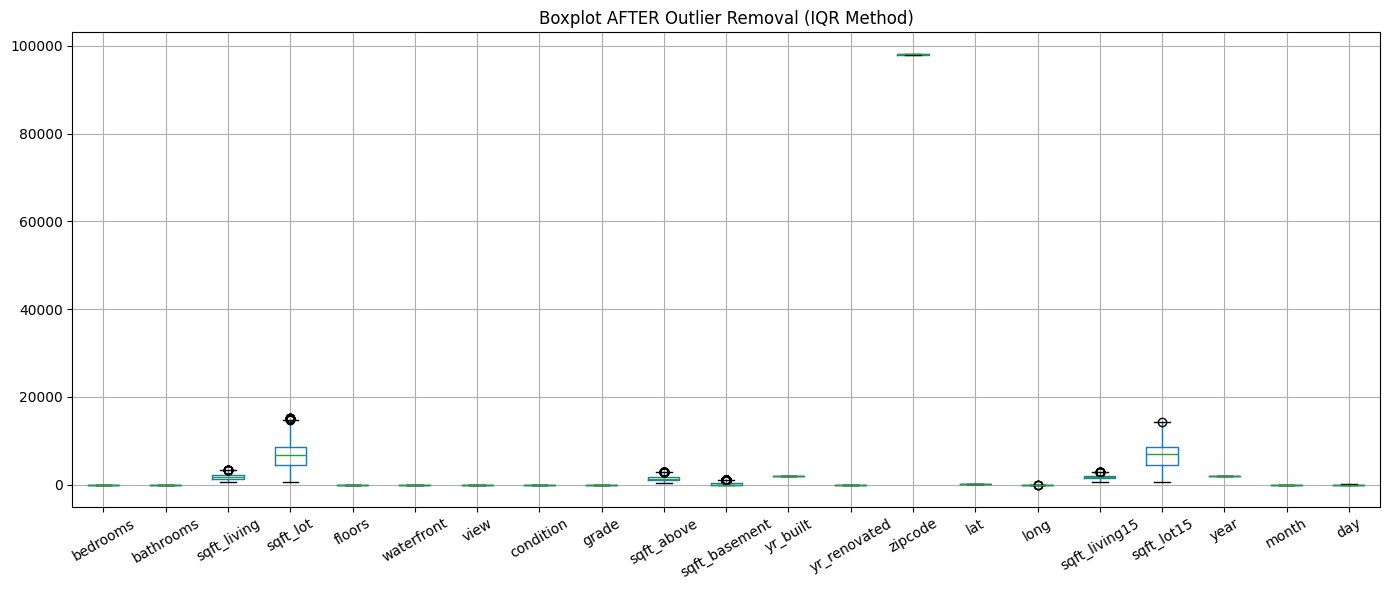

In [21]:
# ---- AFTER Boxplot ----
# Re-defining num_cols for the modified df after outlier removal
import numpy as np
import matplotlib.pyplot as plt

# ---- AFTER Boxplot ----

# Select numeric columns (exclude id & price)
num_cols = df_house.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['id', 'price']]

plt.figure(figsize=(14, 6))
df_house[num_cols].boxplot(rot=30)
plt.title('Boxplot AFTER Outlier Removal (IQR Method)')
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

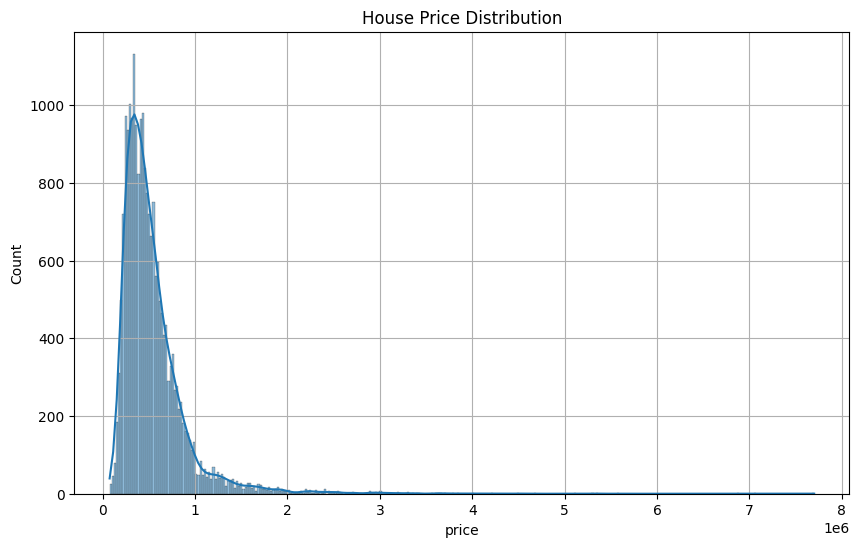

In [22]:
# --- Visualization 1: Target class distribution (Countplot) ---
plt.figure(figsize=(6, 4))
plt.figure(figsize=(10,6))
sns.histplot(df['price'], kde=True)
plt.title("House Price Distribution")
plt.grid()
plt.show()

In [23]:
# Define features (X) and target (y)
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop(columns=['id', 'price'])
y = df['price']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (17290, 19)
Test size : (4323, 19)


### 5. Outlier Detection & Removal using IQR Method

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Select numeric columns (excluding target and ID)
num_cols_house = df_house.select_dtypes(include=np.number).columns.tolist()
num_cols_house = [c for c in num_cols_house if c not in ['id', 'price']]

print('Rows before outlier removal:', len(df_house))

# Apply IQR method to remove outliers from numeric columns
for col in num_cols_house:
    Q1 = df_house[col].quantile(0.25)
    Q3 = df_house[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_house = df_house[(df_house[col] >= lower) & (df_house[col] <= upper)]

print('Rows after outlier removal:', len(df_house))

Rows before outlier removal: 13242
Rows after outlier removal: 12955


### 6. Visualizations

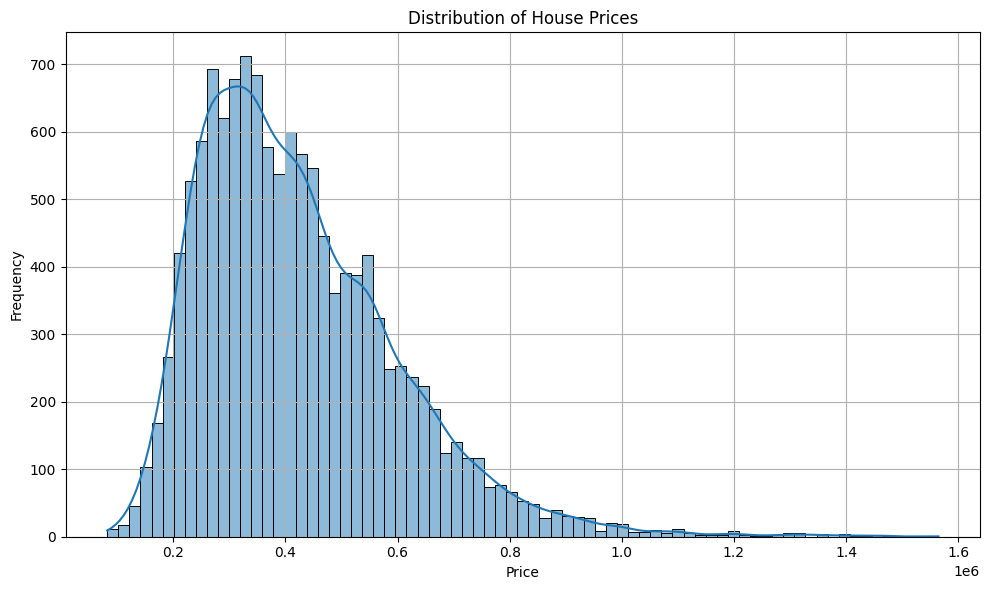

In [25]:
import seaborn as sns

# Distribution of the target variable (price)
plt.figure(figsize=(10, 6))
sns.histplot(df_house['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.grid()
plt.show()

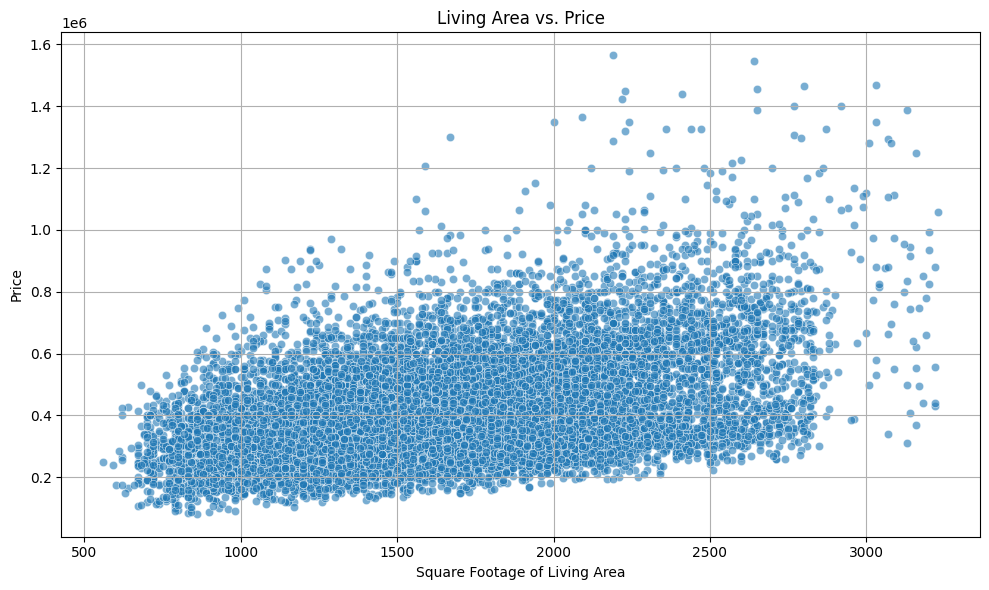

In [26]:
# Scatter plot: Living Area vs. Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sqft_living', y='price', data=df_house, alpha=0.6)
plt.title('Living Area vs. Price')
plt.xlabel('Square Footage of Living Area')
plt.ylabel('Price')
plt.tight_layout()
plt.grid()
plt.show()

### 7. Model Training - Linear Regression

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define features (X) and target (y)
X_house = df_house.drop(columns=['id', 'price'])
y_house = df_house['price']

# Split into train and test sets (80/20)
X_train_house, X_test_house, y_train_house, y_test_house = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)

print('Train size:', X_train_house.shape)
print('Test size :', X_test_house.shape)

Train size: (10364, 21)
Test size : (2591, 21)


In [28]:
# Train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_house, y_train_house)

LinearRegression()

### 8. Model Evaluation

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions on test set
y_pred_house = linear_model.predict(X_test_house)

# Evaluate model
mae = mean_absolute_error(y_test_house, y_pred_house)
mse = mean_squared_error(y_test_house, y_pred_house)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_house, y_pred_house)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.4f}')

Mean Absolute Error (MAE): 77836.49
Mean Squared Error (MSE): 10908100056.98
Root Mean Squared Error (RMSE): 104441.85
R-squared (R2): 0.6300


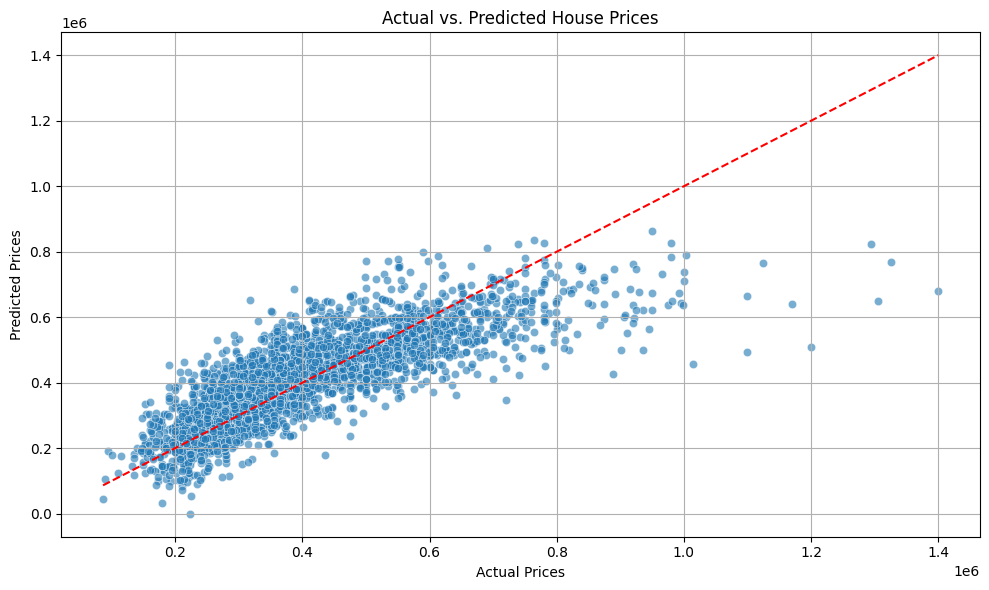

In [30]:
# Plotting actual vs. predicted prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_house, y=y_pred_house, alpha=0.6)
plt.plot([y_test_house.min(), y_test_house.max()], [y_test_house.min(), y_test_house.max()], 'r--')
plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.tight_layout()
plt.grid()
plt.show()